# 의료 데이터 분석 첫걸음
### 아밀로이드 PET 데이터 다뤄보기 (연습용 가상 데이터)

이 노트북은 Python/데이터 분석이 처음인 사람을 위한 **입문용 연습 노트북**입니다.

- 실제 환자 데이터가 아닌 **가상으로 만든 연습용 데이터**를 사용합니다 (개인정보 걱정 없이 연습 가능)
- 데이터 구조는 실제 아밀로이드 PET 임상 데이터와 비슷하게 만들었습니다 (나이, 성별, SUVR 수치, 인지검사 점수, 진단 여부 등)
- 목표: pandas로 데이터 불러오기 → 살펴보기 → 시각화 → 아주 기본적인 분석까지 해보는 것

**나중에 실제 프로젝트에서는** 여기서 만든 가상 데이터 대신, 진짜 데이터(비식별화된 형태)를 불러오는 코드로만 바꾸면 됩니다.

## 1단계. 필요한 도구(라이브러리) 불러오기

- `pandas`: 표(엑셀 같은) 형태의 데이터를 다루는 도구
- `numpy`: 숫자 계산을 도와주는 도구
- `matplotlib`: 그래프를 그리는 도구

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (그래프에서 한글이 깨지지 않도록)
# Google Colab / Ubuntu 환경 기준: 나눔고딕 설치 후 폰트 지정
!apt-get -qq install fonts-nanum > /dev/null 2>&1
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("라이브러리 불러오기 및 한글 폰트 설정 완료!")


라이브러리 불러오기 및 한글 폰트 설정 완료!


## 2단계. 연습용 가상 데이터 만들기

실제 아밀로이드 PET 임상연구에서 흔히 다루는 변수들을 흉내내서 가상 데이터를 만듭니다.

- `age`: 나이
- `sex`: 성별
- `suvr`: 아밀로이드 PET SUVR 수치 (뇌에 쌓인 아밀로이드 양을 나타내는 지표. 높을수록 아밀로이드가 많이 쌓여있음을 의미)
- `mmse`: 간이정신상태검사 점수 (인지기능 평가, 낮을수록 인지저하가 심함)
- `diagnosis`: 진단 결과 (0 = 정상, 1 = 인지저하 의심)

In [2]:
# 재현 가능하도록 랜덤 시드 고정
np.random.seed(42)

n = 200  # 가상 환자 200명

# 진단 그룹을 절반씩 나눠서 생성 (정상 vs 인지저하 의심)
diagnosis = np.array([0]*100 + [1]*100)

# 정상군은 SUVR이 낮고, 인지저하 의심군은 SUVR이 높게 생성
suvr = np.where(diagnosis == 0,
                 np.random.normal(1.1, 0.1, n),   # 정상군: 평균 1.1
                 np.random.normal(1.5, 0.15, n))  # 의심군: 평균 1.5

# 정상군은 MMSE가 높고, 의심군은 낮게 생성
mmse = np.where(diagnosis == 0,
                 np.random.normal(28, 1.5, n),
                 np.random.normal(22, 3, n))

age = np.random.normal(70, 7, n).astype(int)
sex = np.random.choice(['M', 'F'], size=n)

df = pd.DataFrame({
    'age': age,
    'sex': sex,
    'suvr': suvr.round(2),
    'mmse': mmse.round(1),
    'diagnosis': diagnosis
})

print(f"데이터 생성 완료! 총 {len(df)}명")
df.head()

데이터 생성 완료! 총 200명


,age,sex,suvr,mmse,diagnosis
0,76,M,1.15,25.6,0
1,66,F,1.09,27.1,0
2,70,M,1.16,28.0,0
3,66,F,1.25,28.1,0
4,66,M,1.08,27.3,0


## 3단계. 데이터 기본 살펴보기

가장 먼저 하는 일은 항상 "이 데이터가 어떻게 생겼는지" 확인하는 것입니다.

In [3]:
# 데이터 크기 확인 (행, 열)
print("데이터 크기:", df.shape)

# 컬럼(변수) 목록과 타입 확인
df.info()

데이터 크기: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        200 non-null    int64  
 1   sex        200 non-null    str    
 2   suvr       200 non-null    float64
 3   mmse       200 non-null    float64
 4   diagnosis  200 non-null    int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 7.9 KB


In [4]:
# 기본 통계 요약 (평균, 표준편차, 최솟값, 최댓값 등)
df.describe()

,age,suvr,mmse,diagnosis
count,200.000000,200.000000,200.000000,200.000000
mean,70.410000,1.302750,24.949500,0.500000
std,6.703475,0.241625,3.787682,0.501255
min,53.000000,0.840000,15.800000,0.000000
25%,66.000000,1.090000,22.250000,0.000000
50%,70.000000,1.260000,25.650000,0.500000
75%,74.250000,1.502500,27.925000,1.000000
max,87.000000,1.830000,32.600000,1.000000


In [5]:
# 결측치(비어있는 값) 확인 - 실제 임상데이터에서는 매우 중요한 단계!
df.isnull().sum()

age          0
sex          0
suvr         0
mmse         0
diagnosis    0
dtype: int64

## 4단계. 진단 그룹별로 비교해보기

정상군(0)과 인지저하 의심군(1)이 실제로 SUVR, MMSE에서 차이가 나는지 확인해봅니다.

In [6]:
# 진단 그룹별 평균값 비교
df.groupby('diagnosis')[['age', 'suvr', 'mmse']].mean()

,age,suvr,mmse
diagnosis,,,
0,71.11,1.0898,27.915
1,69.71,1.5157,21.984


## 5단계. 그래프로 시각화하기

숫자로 보는 것보다 그래프로 보면 훨씬 직관적으로 이해할 수 있습니다.

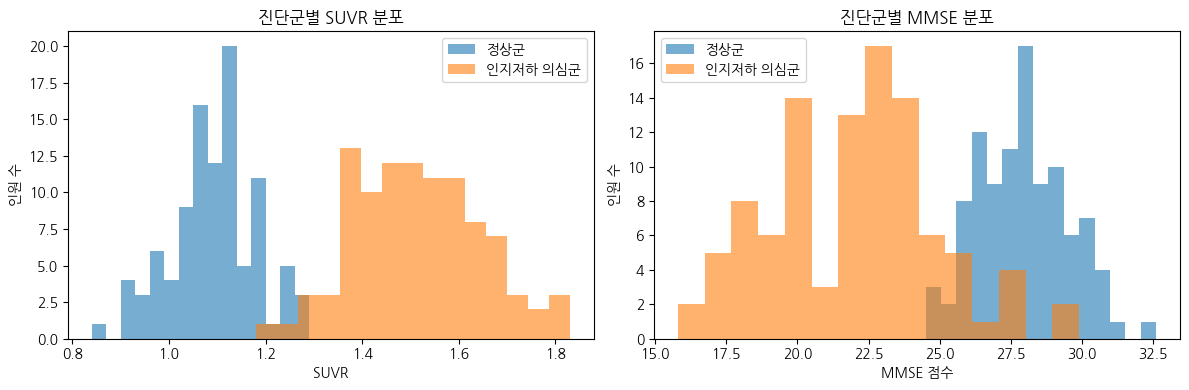

그래프를 보면, SUVR은 의심군이 더 높게, MMSE는 의심군이 더 낮게 분포하는 걸 확인할 수 있습니다.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SUVR 분포 비교 (히스토그램)
axes[0].hist(df[df['diagnosis']==0]['suvr'], bins=15, alpha=0.6, label='정상군')
axes[0].hist(df[df['diagnosis']==1]['suvr'], bins=15, alpha=0.6, label='인지저하 의심군')
axes[0].set_xlabel('SUVR')
axes[0].set_ylabel('인원 수')
axes[0].set_title('진단군별 SUVR 분포')
axes[0].legend()

# MMSE 분포 비교
axes[1].hist(df[df['diagnosis']==0]['mmse'], bins=15, alpha=0.6, label='정상군')
axes[1].hist(df[df['diagnosis']==1]['mmse'], bins=15, alpha=0.6, label='인지저하 의심군')
axes[1].set_xlabel('MMSE 점수')
axes[1].set_ylabel('인원 수')
axes[1].set_title('진단군별 MMSE 분포')
axes[1].legend()

plt.tight_layout()
plt.savefig('suvr_mmse_distribution.png', dpi=100)
plt.show()

print("그래프를 보면, SUVR은 의심군이 더 높게, MMSE는 의심군이 더 낮게 분포하는 걸 확인할 수 있습니다.")

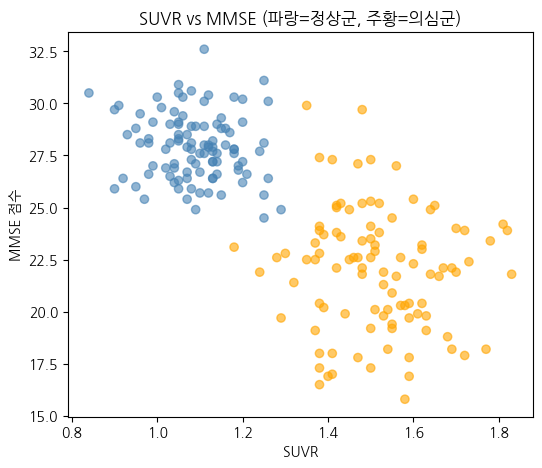

In [8]:
# SUVR과 MMSE의 관계를 산점도로 확인
plt.figure(figsize=(6, 5))
colors = df['diagnosis'].map({0: 'steelblue', 1: 'orange'})
plt.scatter(df['suvr'], df['mmse'], c=colors, alpha=0.6)
plt.xlabel('SUVR')
plt.ylabel('MMSE 점수')
plt.title('SUVR vs MMSE (파랑=정상군, 주황=의심군)')
plt.savefig('suvr_vs_mmse_scatter.png', dpi=100)
plt.show()

## 다음 단계 (앞으로 해볼 것들)

여기까지가 데이터 분석의 가장 기본이 되는 **탐색적 데이터 분석(EDA)**입니다.
이 노트북 자체가 이미 "Python으로 의료 데이터를 다뤄본 경험"의 첫 증거가 될 수 있습니다.

앞으로 확장해볼 수 있는 방향:
- [ ] `scikit-learn`으로 아주 간단한 분류 모델 만들어보기 (SUVR, MMSE, age로 진단 예측)
- [ ] 상관관계 분석 (`df.corr()`)으로 변수 간 관계 파악하기
- [ ] 실제 공개 데이터셋(ADNI, Kaggle Alzheimer's Dataset 등)으로 같은 분석 반복해보기
- [ ] 결과를 README에 정리해서 GitHub에 업로드하기
